# Fake News Detector — Group 14C  
### AI4ALL Ignite — Fall 2024

---

### 1. Setup & Configuration
Importing necessary libraries (Pandas, NLTK, Seaborn) and setting up our sentiment analyzers and word lists.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pathlib import Path
from nltk.sentiment import SentimentIntensityAnalyzer
from better_profanity import profanity
from collections import Counter
# from google import genai

# Note: NLTK resource downloads and SentimentIntensityAnalyzer initialization
# are handled in a dedicated setup cell below to avoid runtime LookupErrors.
profanity.load_censor_words()
sia = None

# --- Define Word Lists ---
OPPOSITION_WORDS = {
    'but', 'however', 'although', 'though', 'yet', 'nevertheless', 
    'nonetheless', 'despite', 'instead', 'contradict', 'conversely'
}

FIRST_PERSON = {'i', 'we', 'me', 'us', 'my', 'our', 'mine', 'ours'}

SECOND_THIRD_PERSON = {
    'you', 'he', 'she', 'they', 'him', 'her', 'them', 
    'your', 'his', 'its', 'their'
}

LOADED_WORDS = {
    'radical', 'extreme', 'crisis', 'shocking', 'scandal', 'banned', 'exposed', 
    'secret', 'illegal', 'destroy', 'betray', 'panic', 'terror', 'myth', 'hoax',
    'conspiracy', 'freedom', 'tyranny', 'patriot', 'traitor', 'insane', 'plot'
}

BAD_WORDS_SET = {str(w).lower() for w in profanity.CENSOR_WORDSET if w}

print("✅ Setup Complete.")

✅ Setup Complete.


In [2]:
# Predeclare `df` for static analysis (Pylance)
from typing import Optional
df: Optional[pd.DataFrame] = None  # will be assigned when data is loaded

In [3]:
# Ensure required NLTK resources are available (downloads if missing)
import nltk
resources = {
    'punkt': 'tokenizers/punkt',
    'stopwords': 'corpora/stopwords',
    'averaged_perceptron_tagger': 'taggers/averaged_perceptron_tagger',
    'vader_lexicon': 'sentiment/vader_lexicon'
}
for name, path in resources.items():
    try:
        nltk.data.find(path)
    except LookupError:
        print(f"Downloading NLTK resource: {name}...")
        try:
            nltk.download(name, quiet=False)
        except Exception as e:
            print(f"Failed to download {name}: {e}")
# Try to initialize SentimentIntensityAnalyzer; fall back safely if unavailable
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    try:
        sia = SentimentIntensityAnalyzer()
    except Exception as e:
        print('Warning: could not initialize SentimentIntensityAnalyzer:', e)
        sia = None
except Exception as e:
    print('Warning: NLTK sentiment module not available:', e)
    sia = None

def get_sentiment(text):
    """Return compound sentiment score or 0.0 if SIA unavailable."""
    if sia is None:
        return 0.0
    return sia.polarity_scores(str(text))['compound']

print('NLTK resources check complete.')

**********************************************************************
  Resource vader_lexicon not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('vader_lexicon')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load sentiment/vader_lexicon.zip/vader_lexicon/vader_lexicon.txt

  Searched in:
    - '/Users/rhodesanchez/nltk_data'
    - '/Users/rhodesanchez/fakeornah/.venv/nltk_data'
    - '/Users/rhodesanchez/fakeornah/.venv/share/nltk_data'
    - '/Users/rhodesanchez/fakeornah/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************

NLTK resources check complete.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:1028)>
[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>


## 1. Imports & Setup

In [4]:
import re
def get_lexical_diversity(text):
    """Calculates vocabulary richness (Unique/Total)."""
    if not isinstance(text, str): return 0
    try:
        tokens = nltk.word_tokenize(text.lower())
        words = [w for w in tokens if w.isalpha()]
    except LookupError:
        words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    return len(set(words)) / len(words) if words else 0

def get_pronoun_counts(text):
    """Returns 1st vs 2nd/3rd person pronoun counts."""
    try:
        words = nltk.word_tokenize(str(text).lower())
    except LookupError:
        words = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    fp = sum(1 for w in words if w in FIRST_PERSON)
    stp = sum(1 for w in words if w in SECOND_THIRD_PERSON)
    return pd.Series([fp, stp], index=['pronoun_1st', 'pronoun_2nd_3rd'])

def get_readability_score(text):
    """Calculates Average Sentence Length (ASL). Higher = Harder."""
    if not isinstance(text, str) or not text: return 0
    try:
        sentences = nltk.sent_tokenize(text)
        words = nltk.word_tokenize(text)
    except LookupError:
        sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
        words = re.findall(r"\b[a-zA-Z]+\b", text)
    return len(words) / len(sentences) if sentences else 0

def get_pos_counts(text):
    """Counts Adjectives (subjectivity) and Verbs (action).
    Always returns a Pandas Series with two numeric values so downstream
    dataframe assignment doesn't get mixed types (tuples vs Series).
    """
    if not isinstance(text, str) or not text:
        return pd.Series([0, 0], index=['pos_adjectives', 'pos_verbs'])
    # Optimization: Only tag first 500 chars to save time
    try:
        tokens = nltk.word_tokenize(text[:500])
        tags = nltk.pos_tag(tokens)
    except LookupError:
        return pd.Series([0, 0], index=['pos_adjectives', 'pos_verbs'])
    adj_count = len([t for _, t in tags if t.startswith('JJ')])
    verb_count = len([t for _, t in tags if t.startswith('VB')])
    return pd.Series([adj_count, verb_count], index=['pos_adjectives', 'pos_verbs'])

def analyze_ngrams(df, n=2, top_k=10):
    """Prints most common phrases."""
    print(f"\n--- 🔍 N-GRAM ANALYSIS (Top {top_k} Phrases) ---")
    try:
        stop = set(nltk.corpus.stopwords.words('english'))
    except LookupError:
        stop = set()
    for label_name, label_val in [("FAKE NEWS", 0), ("TRUE NEWS", 1)]:
        text_data = " ".join(df[df['label'] == label_val]['title'].astype(str))
        try:
            tokens = nltk.word_tokenize(text_data.lower())
        except LookupError:
            tokens = re.findall(r"\b[a-zA-Z]+\b", text_data.lower())
        tokens = [w for w in tokens if w.isalpha() and w not in stop]
        # build ngrams without NLTK if needed
        n_grams = []
        for i in range(len(tokens)-n+1):
            n_grams.append(tuple(tokens[i:i+n]))
        common = Counter(n_grams).most_common(top_k)
        print(f"\n[{label_name}]")
        for phrase, count in common:
            print(f"  {count}: {' '.join(phrase)}")

print("✅ Functions Loaded.")

✅ Functions Loaded.


### 3. Data Pipeline
Loading the `Fake.csv` and `True.csv` datasets, merging them, and running the feature extraction logic on all articles.
> **Note:** This step involves tokenizing 40,000+ articles and may take 1-2 minutes to complete.

In [5]:
# 1. Load Data
try:
    df_fake = pd.read_csv(Path("Dataset") / "Fake.csv")
    df_true = pd.read_csv(Path("Dataset") / "True.csv")
    df_fake['label'] = 0
    df_true['label'] = 1
    df = pd.concat([df_fake, df_true], ignore_index=True)
    print(f"✅ Data Loaded: {len(df)} articles.")
except FileNotFoundError:
    print("❌ Error: 'Dataset' folder not found.")

# 2. Extract Features
print("⚙️  Processing Text... (Please wait)")

# --- Simple Counts (Title & Text) ---
for col in ['title', 'text']:
    suffix = f"_{col}"
    # Word Count & Punctuation
    df[f'word_count{suffix}'] = df[col].apply(lambda x: len(str(x).split()))
    df[f'excl{suffix}'] = df[col].str.count('!')
    df[f'ques{suffix}'] = df[col].str.count(r'\?')
    # Sentiment — use safe wrapper that returns 0.0 if SIA unavailable
    df[f'sentiment{suffix}'] = df[col].apply(get_sentiment)
    # Profanity & Loaded Words
    df[f'profanity{suffix}'] = df[col].apply(lambda x: sum(1 for w in str(x).lower().split() if w in BAD_WORDS_SET))
    df[f'loaded_vocab{suffix}'] = df[col].apply(lambda x: sum(1 for w in str(x).lower().split() if w in LOADED_WORDS))

# --- Complex Metrics ---
df['opposition_count'] = df['text'].apply(lambda x: sum(1 for w in str(x).lower().split() if w in OPPOSITION_WORDS))
df['lexical_diversity'] = df['text'].apply(get_lexical_diversity)
df['readability_score'] = df['text'].apply(get_readability_score)
df[['pronoun_1st', 'pronoun_2nd_3rd']] = df['text'].apply(get_pronoun_counts)

# --- POS Tagging ---
print("   ...Tagging Parts of Speech")
df[['pos_adjectives', 'pos_verbs']] = df['text'].apply(get_pos_counts)

print("✅ Processing Complete! Dataframe is ready.")

✅ Data Loaded: 44898 articles.
⚙️  Processing Text... (Please wait)


   ...Tagging Parts of Speech


✅ Processing Complete! Dataframe is ready.


FEATURES = {
    "word_count": lambda x: len(nltk.word_tokenize(x)),
    "question_marks": lambda x: x.count("?"),
    "negativity": lambda x: sia.polarity_scores(x)["neg"],
    "text_sentiment": lambda x: sia.polarity_scores(x)["compound"],
    "lexical_diversity": lexical_diversity_optimized,
    "profanity_count": fast_profanity_count,
}

## 5. Apply Linguistic Features
This section computes all features for both fake and real datasets.

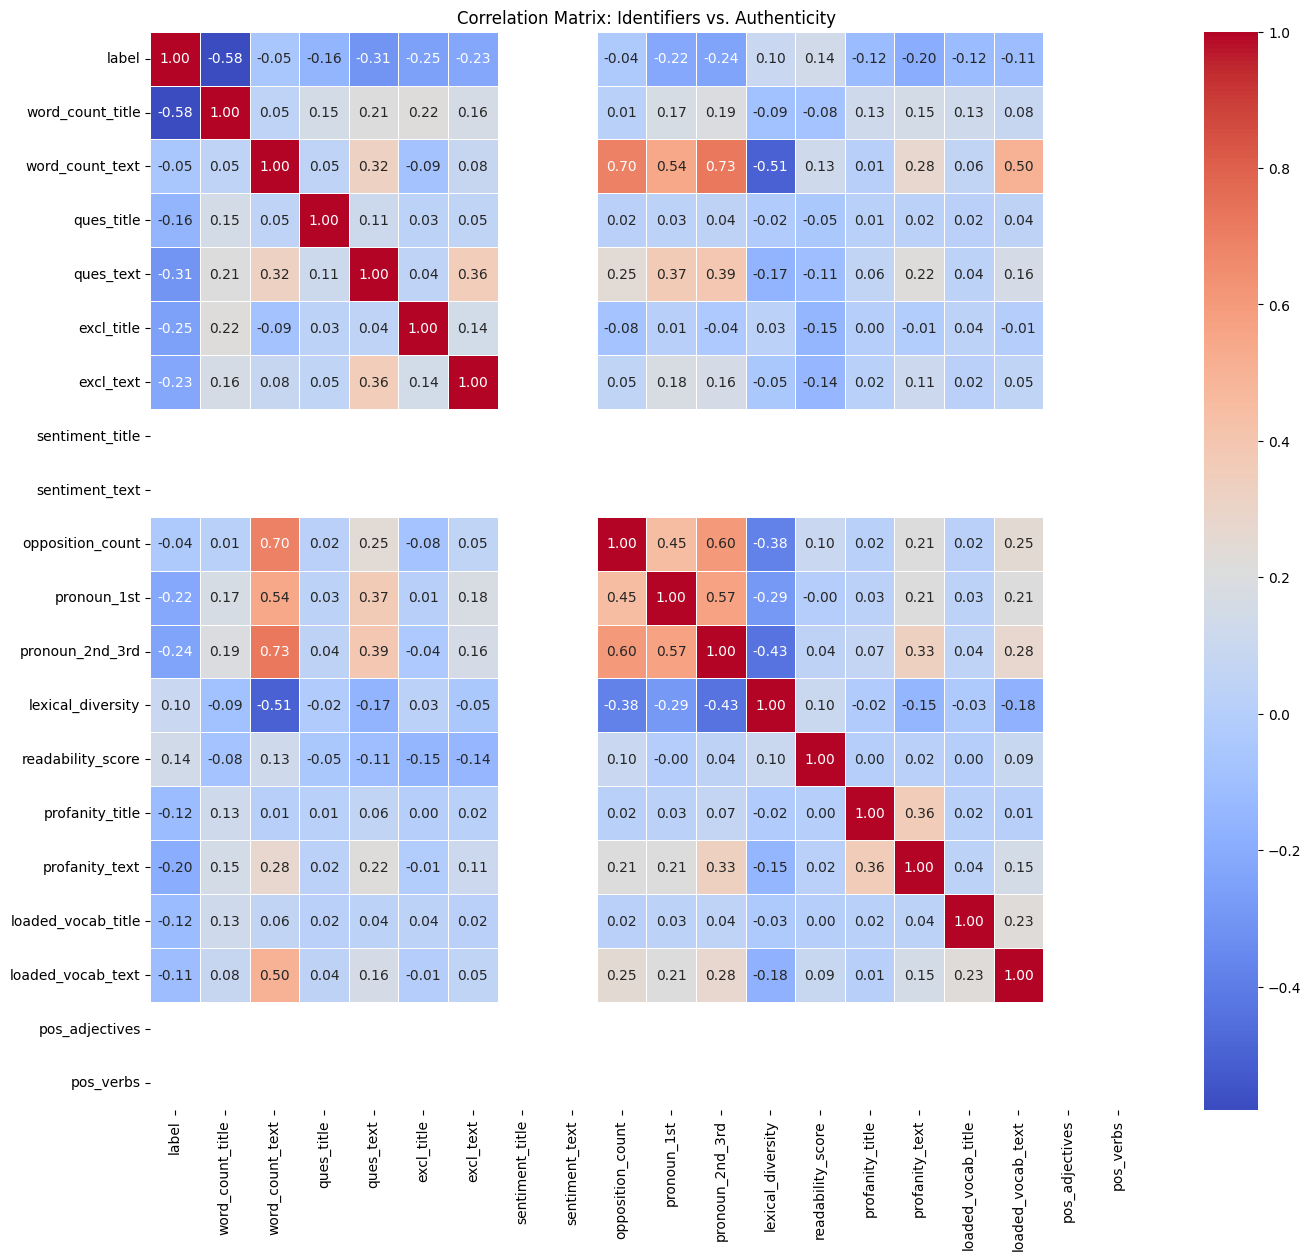


🏆 STRONGEST PREDICTORS OF FAKE NEWS (Negative Correlation):
word_count_title   -0.580489
ques_text          -0.307477
excl_title         -0.253718
pronoun_2nd_3rd    -0.238299
excl_text          -0.226820
Name: label, dtype: float64

🏆 STRONGEST PREDICTORS OF TRUE NEWS (Positive Correlation):
readability_score    0.137146
lexical_diversity    0.096357
opposition_count    -0.036522
word_count_text     -0.053405
loaded_vocab_text   -0.113900
Name: label, dtype: float64

--- 🔍 N-GRAM ANALYSIS (Top 10 Phrases) ---



[FAKE NEWS]
  1464: trump s
  792: donald trump
  681: obama s
  538: it s
  498: u s
  492: president trump
  491: video watch
  423: hillary s
  416: video trump
  408: hillary clinton

[TRUE NEWS]
  4190: u s
  790: white house
  720: north korea
  677: trump s
  513: u n
  362: trump says
  313: trump to
  251: islamic state
  235: supreme court
  210: says he


In [6]:
for name, func in FEATURES.items():
    apply_feature(df_fake, df_true, name, func)

# Pronouns added separately
df_fake[["first_person", "others"]] = df_fake["text"].apply(count_pronouns)
df_true[["first_person", "others"]] = df_true["text"].apply(count_pronouns)

## 6. Combine Datasets for Analysis

In [ ]:
df_fake["is_fake"] = 1
df_true["is_fake"] = 0

df_combined = pd.concat([df_fake, df_true], ignore_index=True)

## 7. Statistical Tests (t-tests)
Testing whether each linguistic feature significantly differs between fake and real news.


In [ ]:
feature_list = list(FEATURES.keys()) + ["first_person", "others"]

ttest_results = {}

for f in feature_list:
    fake_vals = df_fake[f].dropna()
    true_vals = df_true[f].dropna()
    t, p = stats.ttest_ind(fake_vals, true_vals, equal_var=False)
    ttest_results[f] = (t, p)

ttest_results


## 8. Correlation Analysis
Understanding which linguistic features correlate most with the label.

In [ ]:
corr = df_combined.corr()
corr["is_fake"].sort_values(ascending=False)

## 9. Visualizations
Add plots here (correlation heatmap, boxplots, distributions).


## 10. Results, Observations, and Interpretation
Summaries of findings go here.

## 11. Appendix / Experimental Code
Scratch work, alternative models, and tests go here.

XGBoost Accuracy: 0.9151447661469934

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      4696
           1       0.89      0.93      0.91      4284

    accuracy                           0.92      8980
   macro avg       0.92      0.92      0.92      8980
weighted avg       0.92      0.92      0.92      8980


Confusion Matrix:
 [[4218  478]
 [ 284 4000]]


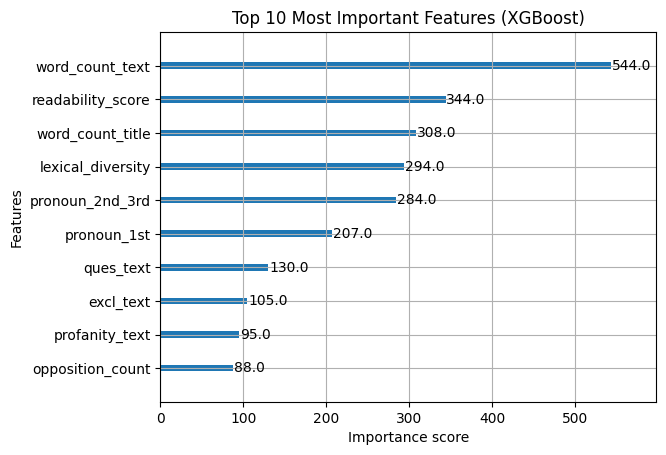

word_count_title        int64
word_count_text         int64
ques_title              int64
ques_text               int64
excl_title              int64
excl_text               int64
sentiment_title       float64
sentiment_text        float64
opposition_count        int64
pronoun_1st             int64
pronoun_2nd_3rd         int64
lexical_diversity     float64
readability_score     float64
profanity_title         int64
profanity_text          int64
loaded_vocab_title      int64
loaded_vocab_text       int64
pos_adjectives          int64
pos_verbs               int64
dtype: object
word_count_title      0
word_count_text       0
ques_title            0
ques_text             0
excl_title            0
excl_text             0
sentiment_title       0
sentiment_text        0
opposition_count      0
pronoun_1st           0
pronoun_2nd_3rd       0
lexical_diversity     0
readability_score     0
profanity_title       0
profanity_text        0
loaded_vocab_title    0
loaded_vocab_text     0
pos_adje

In [7]:
# 5. XGBoost Classification Model: Fake (0) vs Real (1)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Select feature columns (all numeric features you engineered)
feature_cols = [
    'word_count_title', 'word_count_text',
    'ques_title', 'ques_text',
    'excl_title', 'excl_text',
    'sentiment_title', 'sentiment_text',
    'opposition_count',
    'pronoun_1st', 'pronoun_2nd_3rd',
    'lexical_diversity', 'readability_score',
    'profanity_title', 'profanity_text',
    'loaded_vocab_title', 'loaded_vocab_text',
    'pos_adjectives', 'pos_verbs'
]

X = df[feature_cols].copy()
# Ensure features are numeric and fill missing values (XGBoost errors if NaN or non-numeric)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
y = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int)   # 0 = Fake, 1 = True

# 2. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Define XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    # ⚡ If you're in Colab with RAPIDS + GPU, uncomment this:
    # xgboost_device='cuda'
)

# 4. Train
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# 6. (Optional) Feature importance plot
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Most Important Features (XGBoost)")
plt.show()

# Run inside the notebook (new code cell) right before the XGBoost training cell
print(df[feature_cols].dtypes)        # ensure numeric dtypes
print(df[feature_cols].isna().sum()) # show any remaining NaNs per column
print(df[feature_cols].head())       # quick peek at numeric values
print(y.dtype, y.unique()[:10])      # check labels
